In [3]:
import pypsa
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import plotly.express as px
import hvplot.pandas
import matplotlib.colors as mcolors

In [4]:
scenario_name = "nz_2035_exp"  # scenario name, default value is "" for tutorial or default configuration
                    # value shall be non null if a scenario name is specified under the "run" tag in the config file

scenario_subpath = scenario_name + "/" if scenario_name else ""

export_level = 0

n=pypsa.Network(f"../../results/" + scenario_name + f"/postnetworks/elec_s_10_ec_lc3.0_Co2L_3H_2035_0.071_AB_{export_level}export.nc")
regions_onshore = gpd.read_file("../../results/shapes/country_shapes.geojson")

Index(['H2 pipeline NZ.15_1 -> NZ.17_1', 'H2 pipeline NZ.17_1 -> NZ.1_1',
       'H2 pipeline NZ.1_1 -> NZ.11_1'],
      dtype='object', name='name')
Index(['H2 pipeline NZ.15_1 -> NZ.17_1', 'H2 pipeline NZ.17_1 -> NZ.1_1',
       'H2 pipeline NZ.1_1 -> NZ.11_1'],
      dtype='object', name='name')
INFO:pypsa.io:Imported network elec_s_10_ec_lc3.0_Co2L_3H_2035_0.071_AB_0export.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


### Get statistics

In [5]:
n.statistics.dispatch(comps=["Generator", "StorageUnit"]).div(1e6).round(1) # "StorageUnit",

component    carrier                                  
Generator    Coal                                          3.5
             Combined-Cycle Gas                            6.3
             Geothermal                                    9.8
             Offshore Wind (AC)                            0.0
             Offshore Wind (DC)                            0.0
             Oil                                           0.0
             Onshore Wind                                  9.6
             Open-Cycle Gas                                0.3
             Run of River                                  2.8
             Solar                                        13.3
             gas                                          35.8
             residential rural solar thermal               0.0
             residential urban decentral solar thermal     0.0
             services rural solar thermal                  0.0
             services urban decentral solar thermal        0.0


### Get dispatch

In [6]:
threshold_dispatch = 1e6

dispatch = n.statistics.dispatch(bus_carrier="AC")[n.statistics.dispatch(bus_carrier="AC") > 0]
threshold_dispatch_sum = dispatch[dispatch < threshold_dispatch].sum()
dispatch = dispatch[dispatch > threshold_dispatch]
dispatch = pd.DataFrame(dispatch.droplevel(0)).T
dispatch[f"(Dispatch < {threshold_dispatch/1e6} TWh thres.)"] = threshold_dispatch_sum
dispatch = dispatch.T.div(1e6).round(2)

In [35]:
dispatch

,0
carrier,
Coal,3.51
Combined-Cycle Gas,6.34
Geothermal,9.81
Onshore Wind,9.55
Run of River,2.78
Solar,13.26
Reservoir & Dam,32.53
urban central gas CHP,1.25
(Dispatch < 1.0 TWh thres.),0.78


### RES share

In [27]:
def get_res_share(dispatch):

    res_techs = [
    "Geothermal",
    "Offshore Wind (AC)",
    "Offshore Wind (DC)",
    "Onshore Wind",
    "Run of River",
    "Solar",
    "Reservoir & Dam",
    ]

    fossil_techs = [
        "Coal",
        "Combined-Cycle Gas",
        "Open-Cycle Gas",
        "urban central gas CHP",
        "Oil",
    ]

    re = dispatch[dispatch.index.isin(res_techs)].sum().values[0]
    fossil = dispatch[dispatch.index.isin(fossil_techs)].sum().values[0]

    # Check, if re + fossil = total dispatch - threshold
    if abs(dispatch.sum().values[0] - threshold_dispatch_sum/1e6 - re - fossil) > 0.01:
        raise ValueError("Sum of dispatches does not match threshold dispatch sum")

    res_share = re / (re + fossil)


    return res_share

In [29]:
re_share = get_res_share(dispatch)
print(f"The share of renewable dispatch is {re_share:.2%}.")

The share of renewable dispatch is 85.95%.


### Fossil CF

In [14]:
cf = n.statistics.capacity_factor(comps=["Generator", "StorageUnit", "Link"]).round(2)
cf = cf.droplevel(0)

In [15]:
cf[cf.index.isin(fossil_techs)]

carrier
Coal                     0.80
Combined-Cycle Gas       0.39
Oil                      0.02
Open-Cycle Gas           0.07
Open-Cycle Gas           0.14
urban central gas CHP    0.71
dtype: float64

### Installed capacity

In [16]:
n.statistics.optimal_capacity(comps=["Generator"]).div(1e3).round(1)

component  carrier                                  
Generator  Coal                                          0.5
           Combined-Cycle Gas                            1.8
           Geothermal                                    1.1
           Offshore Wind (AC)                            0.0
           Offshore Wind (DC)                            0.0
           Oil                                           0.2
           Onshore Wind                                  3.5
           Open-Cycle Gas                                0.5
           Run of River                                  0.4
           Solar                                        10.5
           gas                                           4.5
           residential rural solar thermal               0.0
           residential urban decentral solar thermal     0.0
           services rural solar thermal                  0.0
           services urban decentral solar thermal        0.0
           urban central solar t

In [17]:
n.generators[n.generators.p_nom_extendable==True].carrier.unique()

array(['onwind', 'solar', 'OCGT', 'offwind-ac', 'offwind-dc', 'gas',
       'residential rural solar thermal', 'services rural solar thermal',
       'residential urban decentral solar thermal',
       'services urban decentral solar thermal',
       'urban central solar thermal'], dtype=object)

### Storages

In [18]:
n.statistics.optimal_capacity(comps=["Store"]).div(1e3).round(1)

component  carrier                                
Store      H2                                          328042.1
           Li ion                                          18.3
           Oil                                        1499957.6
           battery                                          0.0
           biogas                                         500.0
           co2                                          33285.9
           co2 stored                                       0.1
           gas                                        5017861.8
           residential rural water tanks                    0.0
           residential urban decentral water tanks          0.0
           services rural water tanks                       0.0
           services urban decentral water tanks             0.0
           solid biomass                                40000.0
           urban central water tanks                        0.0
Name: e_nom_opt, dtype: float64

In [19]:
n.statistics.installed_capacity(comps=["StorageUnit"])

component    carrier        
StorageUnit  Reservoir & Dam    4782.961783
Name: p_nom, dtype: float64

<AxesSubplot:xlabel='snapshot'>

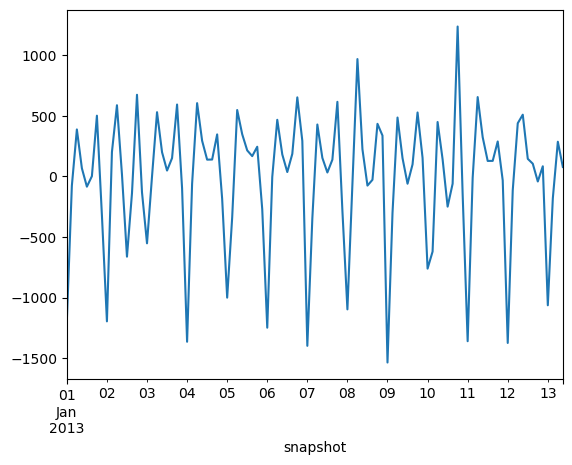

In [20]:
n.stores_t.p.loc[:, n.stores[n.stores.carrier=="Li ion"].index].sum(axis=1).iloc[0:100].plot()

### Electrolysis flh, emissions, hourly energy balance

In [21]:
cf_ely = n.statistics.capacity_factor(comps=["Link"]).droplevel(0).loc["H2 Electrolysis"]
print(f"The capacity factor of the electrolysis is {cf_ely:.2%}.")

The capacity factor of the electrolysis is 64.34%.


### Emissions

Approx 5 MtCO2 each from coal and gas emissions, but only 4.2 MtCO2 from the power sector: https://www.iea.org/countries/new-zealand/emissions

In [36]:
def get_emissions(dispatch):


    emissions = dispatch.loc[["Coal", "Combined-Cycle Gas"]].iloc[:,0].values * n.carriers.loc[["coal", "CCGT"], "co2_emissions"].values * (1/n.generators.groupby("carrier")["efficiency"].mean().loc[["coal", "CCGT"]].values)
    
    return emissions.sum()

In [37]:
get_emissions(dispatch)

5.802570532915361

In [22]:
emissions = dispatch.loc[["Coal", "Combined-Cycle Gas"]].iloc[:,0].values * n.carriers.loc[["coal", "CCGT"], "co2_emissions"].values * (1/n.generators.groupby("carrier")["efficiency"].mean().loc[["coal", "CCGT"]].values)

In [23]:
print(f"The emissions of coal and CCGT are {emissions.sum():.2f} MtCO2")

The emissions of coal and CCGT are 5.80 MtCO2


### Hourly energy balance